# Visualize distributions: histograms and density plots
## Single variable distribution
### Histogram

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import tight_layout

titanic_passenger = pd.read_csv("../06-Exploratory_data_analysis/data/Titanic-Dataset.csv")

titanic_passenger.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_passenger['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Text(0.5, 0, 'Age (year)')

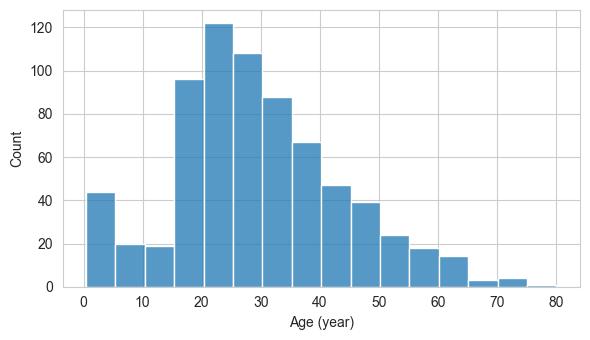

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

sns.histplot(data=titanic_passenger, x='Age', binwidth=5,
             ax=ax)

plt.xlabel("Age (year)")

Histograms are generated by binning the data (see Demo 06-04), so how the figure looks like depends on the bin width.

When making a histogram, always explore multiple bin widths.

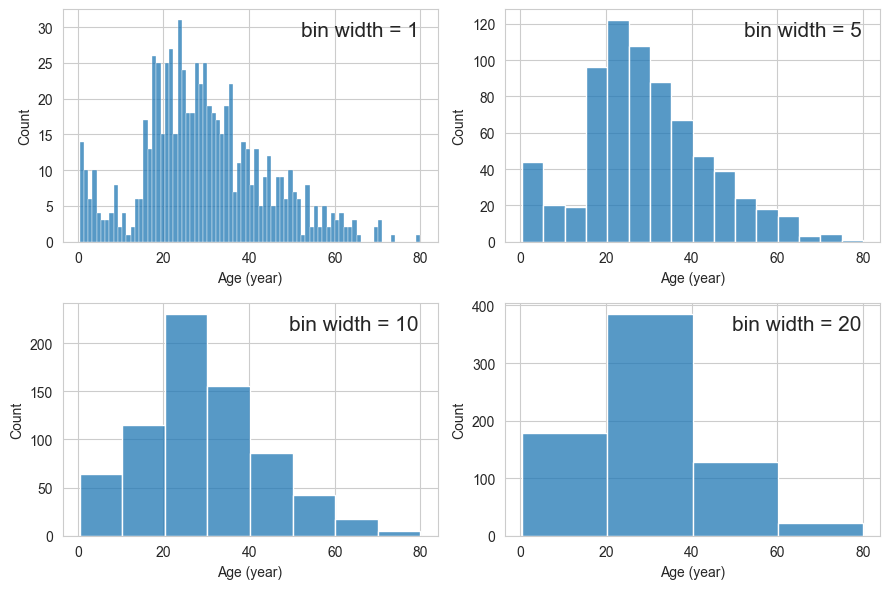

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9,6), tight_layout=True)

for bin_width, ax in zip([1, 5, 10, 20], axes.flat):
    sns.histplot(data=titanic_passenger, x='Age', binwidth=bin_width, ax=ax)
    ax.set_xlabel("Age (year)")
    ax.text(.95, .95, f'bin width = {bin_width}',
            transform=ax.transAxes, ha='right', va='top', fontsize=15)


### Density plots

"In a density plot, we attempt to visualize the underlying probability distribution of the data by drawing an appropriate continuous curve.

This curve needs to be estimated from the data, and the most commonly used method for this estimation procedure is called _kernel density estimation_. In kernel density estimation, we draw a continuous curve (the kernel) with a small width (controlled by a parameter called _bandwidth_) at the location of each data point, and then we add up all these curves to obtain the final density estimate. The most widely used kernel is a Gaussian kernel (i.e., a Gaussian bell curve), but there are many other choices." (Claus Wilke)

In seaborn, we use kde plots (`sns.kdeplot()` or `sns.displot(kind='kde')` or `sns.histplot(kde=True)`), which stand for kernal density estimation.

Text(0.5, 0, 'Age (year)')

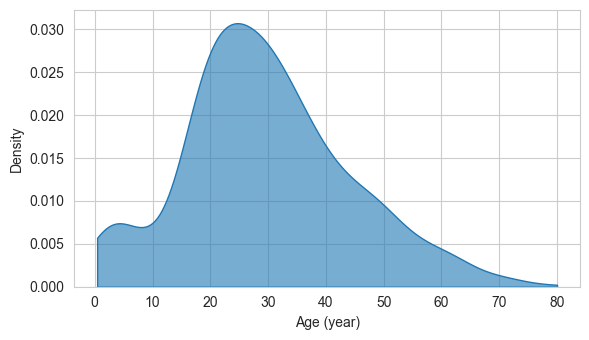

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

sns.kdeplot(data=titanic_passenger, x='Age',
            fill=True, alpha=0.6,
            bw_adjust=1, # default bw_adjust = 1
            cut=0, # set cut=0 because age cannot be negative
            ax=ax)
ax.set_xlabel("Age (year)")

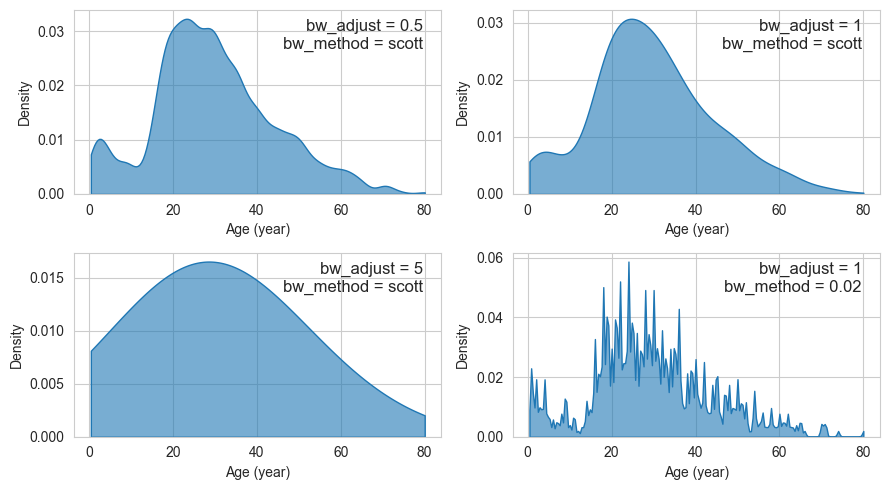

In [58]:
# try adjust the bandwidth

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9,5), tight_layout=True)

for bw_adjust, bw_method, ax in zip([0.5, 1, 5, 1],
                                    ['scott', 'scott', 'scott', 0.02],
                                    axes.flat):
    sns.kdeplot(data=titanic_passenger, x='Age', fill=True,
                alpha=0.6, bw_adjust=bw_adjust, bw_method=bw_method,
                cut=0,ax=ax)
    ax.set_xlabel("Age (year)")
    ax.text(.95, .95, f'bw_adjust = {bw_adjust}\nbw_method = {bw_method}',
            transform=ax.transAxes, ha='right', va='top', fontsize=12)


## Visualize multiple variables' distributions
Example: we want to see the distribution of ages of male and female passengers on Titanic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_passenger = pd.read_csv("../06-Exploratory_data_analysis/data/Titanic-Dataset.csv")

titanic_passenger.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


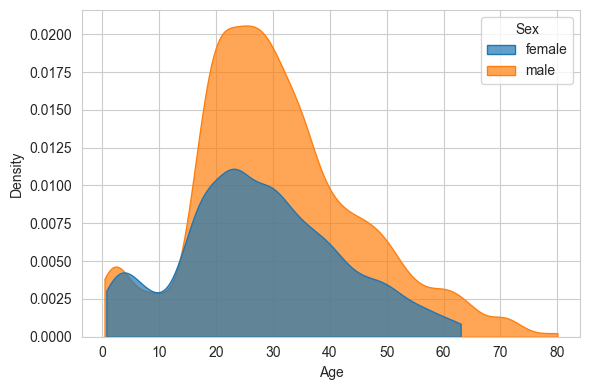

In [17]:
# Plot overlapping KDE plot

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), tight_layout=True)

g=sns.kdeplot(data=titanic_passenger, x='Age', hue='Sex', hue_order=['female','male'],fill=True, alpha=0.7,
              cut=0, bw_adjust=0.6, ax=ax)


## Empirical Cumulative Distribution Function (ECDF)

In [34]:
import pandas as pd

# read the data
nls97 = pd.read_csv("../05-data_cleaning/data/nls97.csv")

Text(0.05, 0.05, 'Descending cumulative distribution')

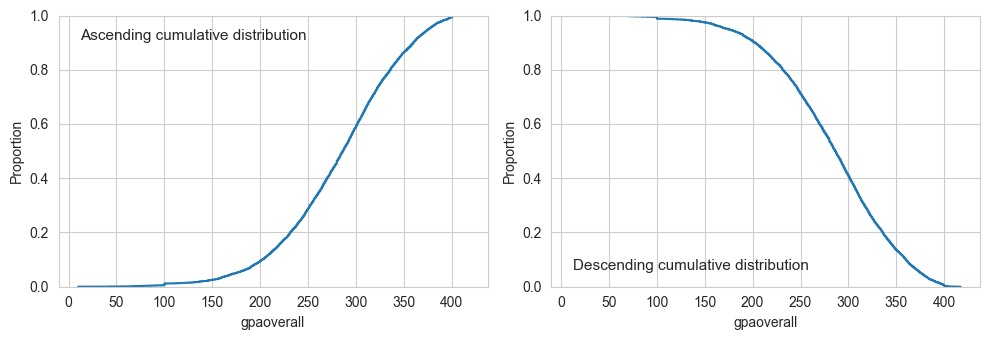

In [66]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,3.5), tight_layout=True, sharex=True)

# plot an ascending cumulative distribution plot
sns.ecdfplot(data=nls97, x='gpaoverall', stat='proportion',ax=axes.flat[0])
axes.flat[0].text(0.05, .95, "Ascending cumulative distribution",
            transform=axes.flat[0].transAxes, ha='left', va='top', fontsize=11)

# plot an ascending cumulative distribution plot
sns.ecdfplot(data=nls97, x='gpaoverall', stat='proportion',ax=axes.flat[1], complementary=True)
axes.flat[1].text(.05, .05, "Descending cumulative distribution",
            transform=axes.flat[1].transAxes, ha='left', va='bottom', fontsize=11)


### Log-transform highly-skewed distribution

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

county_patents = pd.read_csv("../06-Exploratory_data_analysis/data/county_patent_gender_20260112.csv")
county_patents.head()

,disambig_state,state_fips,county,county_fips,patent_count,patent_with_women_count,patent_with_women_pct,patent_with_women_pct_log_log
0,AK,2,Aleutians East,13,7,0,0.000000,0.000000
1,AK,2,Aleutians West Census Area,16,2,0,0.000000,0.000000
2,AK,2,Anchorage,20,240,43,17.916667,0.689942
3,AK,2,Anchorage Municipality,20,2,0,0.000000,0.000000
4,AK,2,Fairbanks North Star,90,55,5,9.090909,0.445119


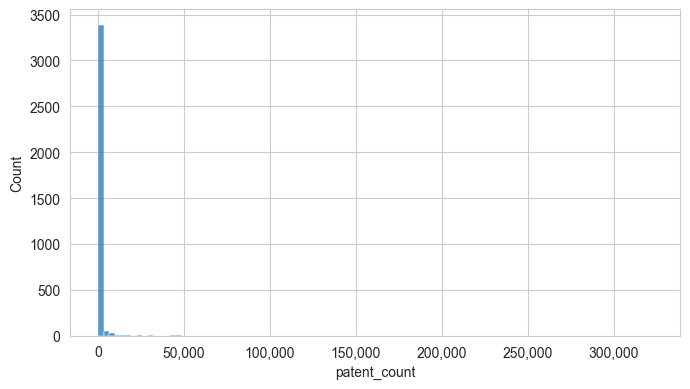

In [75]:
import matplotlib as mpl

fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,4), tight_layout=True)

sns.histplot(data=county_patents['patent_count'], kde=False,
             bins=100, ax=ax)

# to add thousand separator to the xasis
ax.get_xaxis().set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

<Axes: xlabel='patent_count', ylabel='Proportion'>

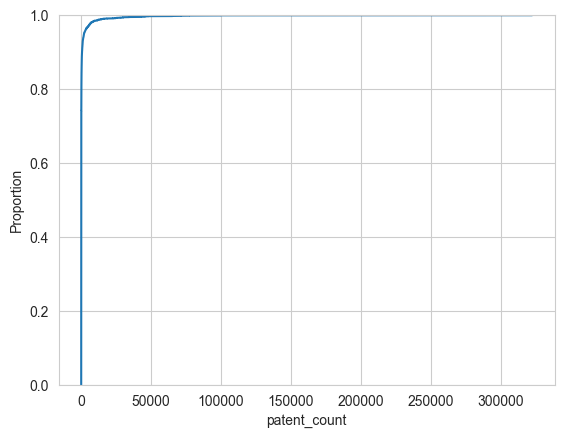

In [76]:
sns.ecdfplot(data=county_patents['patent_count'])

As you can see from the histogram and ecdf plot above, the patent count per county is very skewed.

<Axes: xlabel='patent_count', ylabel='Proportion'>

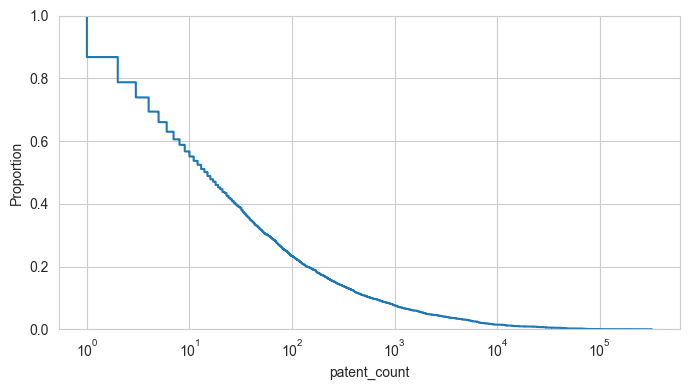

In [37]:
# plot ecdf in log scale

fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,4), tight_layout=True)

sns.ecdfplot(data=county_patents, x='patent_count',complementary=True, log_scale=(True, False), ax=ax)

## Q-Q plots

Quantile-quantile (q-q) plots are useful visualizations when we want to determine to what extent the observed data points do or do not follow a given distribution.

The data is sorted in ascending order and divided into quantiles. These are plotted against the corresponding quantiles of a theoretical distribution. A 45-degree reference line is often included. If the data points follow this line, the distribution are similar.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
# read the data
nls97 = pd.read_csv("../05-data_cleaning/data/nls97.csv")
nls97.head()

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
1,100139,Male,9,1983,12.0,Married,2.0,0.0,120000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
2,100284,Male,11,1984,7.0,Never-married,1.0,0.0,58000.0,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
3,100292,Male,4,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,NaN,NaN,NaN,NaN
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled


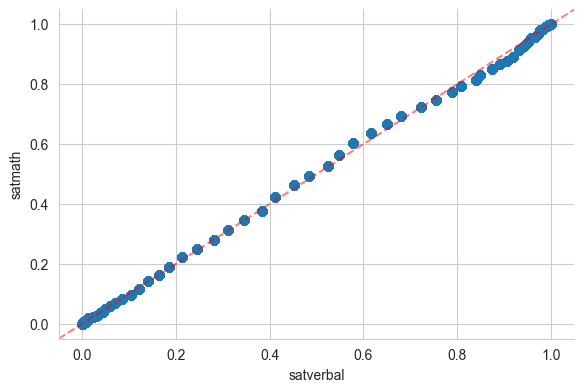

In [31]:
from seaborn_qqplot import pplot

pplot(nls97.dropna(subset=['satverbal','satmath']), x="satverbal", y="satmath", kind='pp', height=4, aspect=1.5)

plt.axline((0, 0), slope=1, color='r', linestyle='--', alpha=0.5)

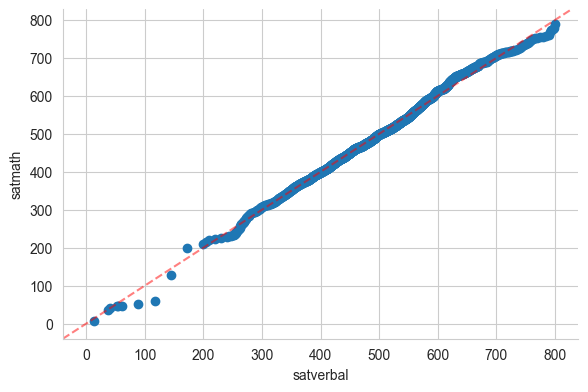

In [32]:
pplot(nls97, x="satverbal", y="satmath", kind='qq', height=4, aspect=1.5)

plt.axline((0, 0), slope=1, color='r', linestyle='--', alpha=0.5)

### Theoretical vs observed
let's assume the theoretical distribution of GPA is normally distributed.

Let's test it using q-q plot

In [26]:
observed = nls97['gpaoverall'].dropna().reset_index(drop=True)
mean_value, std_value, data_size = observed.mean(), observed.std(), len(observed)
rng = np.random.default_rng()
theoretical = pd.Series(rng.normal(loc=mean_value, scale=std_value, size=data_size),name='theoretical')

plot_df = pd.DataFrame({
    "observed": observed,
    "theoretical": theoretical,
})
plot_df.head()

,observed,theoretical
0,306.0,369.201017
1,345.0,321.430685
2,291.0,279.596071
3,246.0,338.361684
4,251.0,358.466989


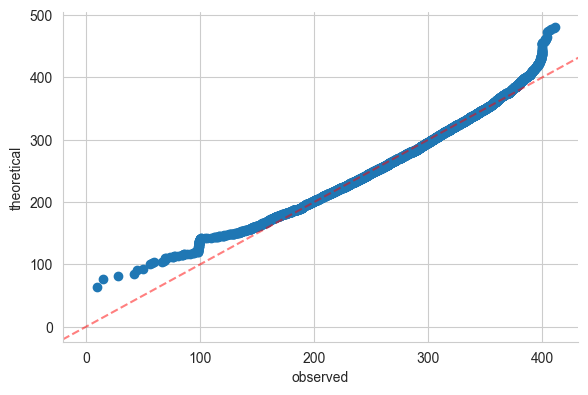

In [33]:
pplot(data=plot_df, x='observed', y='theoretical', kind='qq', height=4, aspect=1.5)

plt.axline((0, 0), slope=1, color='r', linestyle='--', alpha=0.5)

## Plotting many distributions
### Multiple box, boxen, violin, and strip (jittered) plots

Stony Brook daily temperature in 2025, data is from [Stony Brook Health Sciences Center Weather Station](https://www.somassbu.org/wx/DATA/HSC/WX-HSC4.php?yr=2025&mo=12)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# read the data
sbu_temperature = pd.read_csv("./data/stony_brook_daily_temperature_2025.csv")
sbu_temperature.head()

,month,day,average_temperature
0,1,1,7.5
1,1,2,3.3
2,1,3,0.6
3,1,4,-1.5
4,1,5,-2.3


Text(0.5, 0.98, 'Daily temperature in Stony Brook in 2025 (°C)')

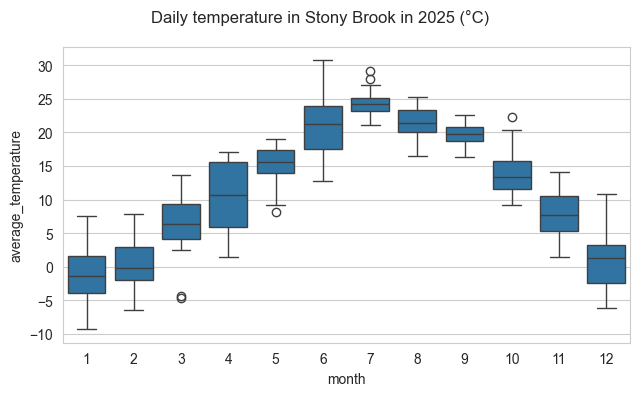

In [63]:
# box plots
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(6.5,4), tight_layout=True)

g=sns.boxplot(data=sbu_temperature, x='month', y='average_temperature', ax=ax)
plt.suptitle(f"Daily temperature in Stony Brook in 2025 (°C)")

Text(0.5, 0.98, 'Daily temperature by month in Stony Brook in 2025 (°C)')

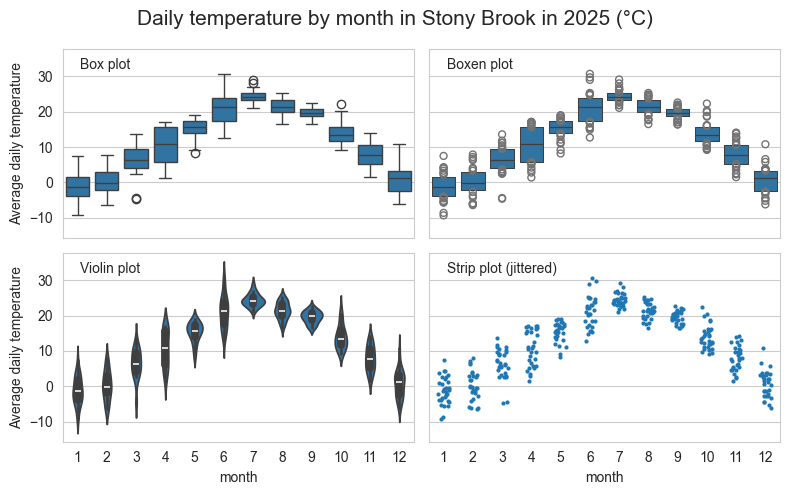

In [73]:
from functools import partial

fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(8,5), tight_layout=True, sharex=True, sharey=True)

plot_types = {
    "Box plot":sns.boxplot,
    "Boxen plot": sns.boxenplot,
    "Violin plot": sns.violinplot,
    "Strip plot (jittered)": partial(sns.stripplot, jitter=0.2, size=3),}


for ax, (plot_type_name, plot_type) in zip(axes.flat, plot_types.items()):
    g=plot_type(data=sbu_temperature, x='month', y='average_temperature', ax=ax)
    ax.text(.05, .95, plot_type_name,
            transform=ax.transAxes, ha='left', va='top')
    ax.set_ylabel("Average daily temperature")

plt.suptitle("Daily temperature by month in Stony Brook in 2025 (°C)", fontsize=15)

/Users/jieswang/PycharmProjects/EST389_371_2026_spring/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 16.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jieswang/PycharmProjects/EST389_371_2026_spring/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jieswang/PycharmProjects/EST389_371_2026_spring/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0.5, 0.98, 'Daily temperature in Stony Brook in 2025 (°C)')

/Users/jieswang/PycharmProjects/EST389_371_2026_spring/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jieswang/PycharmProjects/EST389_371_2026_spring/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 19.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jieswang/PycharmProjects/EST389_371_2026_spring/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 12.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


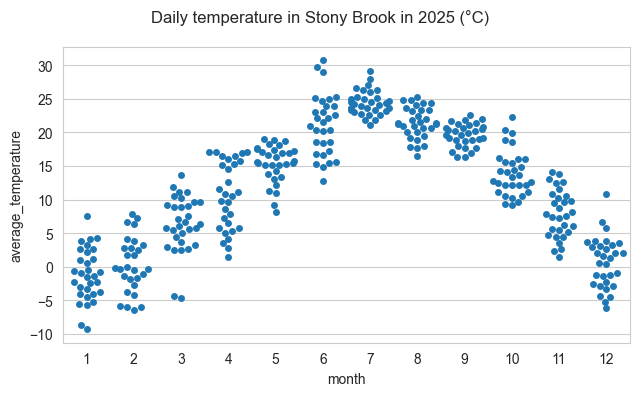

In [3]:
# swarm plots
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(6.5,4), tight_layout=True)

g=sns.swarmplot(data=sbu_temperature, x='month', y='average_temperature', ax=ax)
plt.suptitle(f"Daily temperature in Stony Brook in 2025 (°C)")

### Ridgeline plot

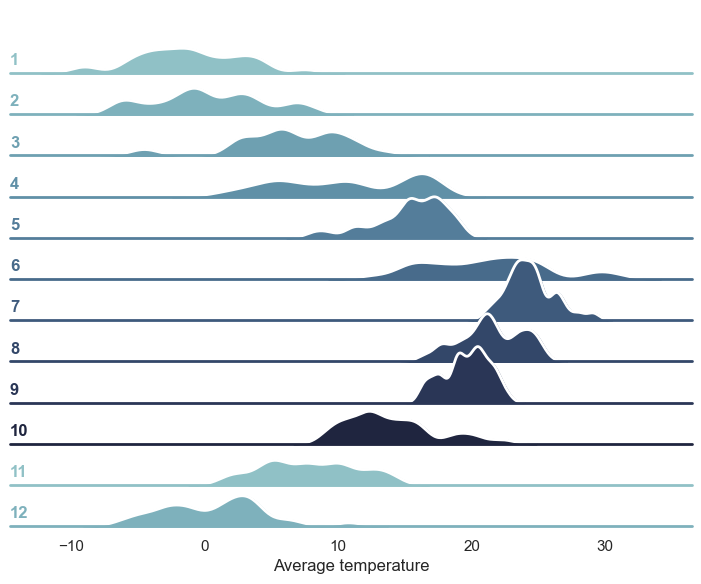

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the data
sbu_temperature = pd.read_csv("./data/stony_brook_daily_temperature_2025.csv")

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(sbu_temperature, row="month", hue="month", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "average_temperature",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "average_temperature", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "average_temperature")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.35)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("Average temperature")


warnings.filterwarnings("ignore")